# Monte Carlo-анализ вероятности пробоя

В этом ноутбуке исследуется влияние базового порога пробоя

$$
E_{\mathrm{bd}}^{(0)}
$$

на вероятность полного электрического пробоя.

На первом этапе фиксируются:

$$
\eta,\qquad
k,\qquad
l_c,
$$

а также одна реализация неоднородного материала

$$
S(x,y).
$$

Для каждого значения $E_{\mathrm{bd}}^{(0)}$ выполняется множество
независимых стохастических реализаций роста канала.

Основная исследуемая величина:

$$
p(E_{\mathrm{bd}}^{(0)})
=
P\left(
\mathrm{breakdown}
\mid
E_{\mathrm{bd}}^{(0)}, S(x,y)
\right).
$$

Нас интересуют:

- форма зависимости $P_{\mathrm{breakdown}}(E_{\mathrm{bd}}^{(0)})$;
- область перехода между полным пробоем и остановкой канала;
- положение середины перехода, где $P_{\mathrm{breakdown}} \approx 0.5$;
- статистическая неопределённость оценки вероятности.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from joblib import Parallel, delayed

from src.config import SimulationConfig
from src.simulator import run_simulation

In [2]:
nx = 128
ny = 128

eta = 1.5
correlation_length = 5.0
weibull_shape = 5.0

disorder_seed = 123

master_seed_pilot = 20260918
master_seed_main = 20260919

n_pilot = 100
n_main = 400

alpha = 0.05
confidence_level = 0.95

In [3]:
def make_random_seed(master_seed, threshold, replicate):
    threshold_key = int(round(threshold * 1_000_000))
    seed_sequence = np.random.SeedSequence([
        master_seed,
        threshold_key,
        replicate
    ])
    random_seed = seed_sequence.generate_state(1, dtype=np.uint64)[0]

    return int(random_seed)

In [4]:
thresholds_pilot = [
    3.8,
    4.0,
    4.2,
    4.3,
    4.4,
    4.5,
    4.6,
    4.7,
    4.75,
    4.8,
]

In [5]:
def run_one(threshold, replicate, master_seed):
    random_seed = make_random_seed(master_seed, threshold, replicate)
    config = SimulationConfig(
        nx=nx,
        ny=ny,
        eta=eta,
        correlation_length=correlation_length,
        weibull_shape=weibull_shape,
        mean_breakdown_field=threshold,
        disorder_seed=disorder_seed,
        random_seed=random_seed
    )

    field, history, breakdown = run_simulation(config)
    if breakdown:
        status = "breakdown"
    elif len(history) == 0:
        status = "no_start"
    elif len(history) >= config.max_steps:
        status = "max_steps"
    else:
        status = "arrested"

    if np.any(field.channel):
        max_y = int(np.max(np.where(field.channel)[0]))
    else:
        max_y = 0

    height_fraction = max_y / (ny - 1)

    return {
        "threshold": threshold,
        "replicate": replicate,
        "random_seed": random_seed,
        "status": status,
        "steps": len(history),
        "max_y": max_y,
        "height_fraction": height_fraction,
    }

In [11]:
cpu_count = os.cpu_count() or 2

n_jobs = max(
    1,
    min(8, cpu_count - 1),
)

print("CPU count:", cpu_count)
print("n_jobs:", n_jobs)

CPU count: 12
n_jobs: 8


In [12]:
from time import perf_counter
from joblib import parallel_config

start_time = perf_counter()

with parallel_config(
    backend="loky",
    inner_max_num_threads=1,
):
    pilot_records = Parallel(
        n_jobs=n_jobs,
        verbose=10,
    )(
        delayed(run_one)(
            threshold=row.threshold,
            replicate=int(row.replicate),
            master_seed=master_seed_pilot,
        )
        for row in pilot_design.itertuples()
    )

elapsed_time = perf_counter() - start_time

print(f"Elapsed time: {elapsed_time:.2f} s")

pilot_results = pd.DataFrame(
    pilot_records
)

pilot_results.head()

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 tasks      | elapsed:  1.3min
[Parallel(n_jobs=8)]: Done   9 tasks      | elapsed:  2.7min
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:  3.3min
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:  5.6min
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:  7.1min
[Parallel(n_jobs=8)]: Done  45 tasks      | elapsed:  9.2min
[Parallel(n_jobs=8)]: Done  56 tasks      | elapsed: 11.2min
[Parallel(n_jobs=8)]: Done  69 tasks      | elapsed: 13.4min
[Parallel(n_jobs=8)]: Done  82 tasks      | elapsed: 15.9min
[Parallel(n_jobs=8)]: Done  97 tasks      | elapsed: 17.4min
[Parallel(n_jobs=8)]: Done 112 tasks      | elapsed: 18.8min
[Parallel(n_jobs=8)]: Done 129 tasks      | elapsed: 20.5min
[Parallel(n_jobs=8)]: Done 146 tasks      | elapsed: 22.0min
[Parallel(n_jobs=8)]: Done 165 tasks      | elapsed: 23.5min
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed: 25.1min
[Parallel(

Elapsed time: 3493.06 s


[Parallel(n_jobs=8)]: Done 1000 out of 1000 | elapsed: 58.2min finished


,threshold,replicate,random_seed,status,steps,max_y,height_fraction
0,3.8,0,5258355502448997756,breakdown,309,127,1.0
1,3.8,1,14749953355623421033,breakdown,321,127,1.0
2,3.8,2,2487937422954893541,breakdown,320,127,1.0
3,3.8,3,17252983447291468214,breakdown,264,127,1.0
4,3.8,4,8001508951503548358,breakdown,325,127,1.0


In [13]:
outcome_counts = pd.crosstab(
    pilot_results["threshold"],
    pilot_results["status"],
)

outcome_counts

status,arrested,breakdown
threshold,,
3.80,6,94
4.00,12,88
4.20,21,79
4.30,35,65
4.40,40,60
4.50,49,51
4.60,60,40
4.70,89,11
4.75,90,10


In [14]:
breakdown_summary = (
    pilot_results
    .assign(
        breakdown=pilot_results["status"].eq("breakdown")
    )
    .groupby("threshold")["breakdown"]
    .agg(["sum", "count", "mean"])
    .reset_index()
)

breakdown_summary = breakdown_summary.rename(
    columns={
        "sum": "n_breakdown",
        "count": "n",
        "mean": "p_breakdown",
    }
)

breakdown_summary

,threshold,n_breakdown,n,p_breakdown
0,3.80,94,100,0.94
1,4.00,88,100,0.88
2,4.20,79,100,0.79
3,4.30,65,100,0.65
4,4.40,60,100,0.60
5,4.50,51,100,0.51
6,4.60,40,100,0.40
7,4.70,11,100,0.11
8,4.75,10,100,0.10
9,4.80,7,100,0.07


In [15]:
z = norm.ppf(
    1 - alpha / 2
)


def wilson_interval(k, n):
    p = k / n

    denominator = (
        1 + z**2 / n
    )

    center = (
        p + z**2 / (2 * n)
    ) / denominator

    half_width = (
        z
        / denominator
        * np.sqrt(
            p * (1 - p) / n
            + z**2 / (4 * n**2)
        )
    )

    return (
        center - half_width,
        center + half_width,
    )

intervals = breakdown_summary.apply(
    lambda row: wilson_interval(
        int(row["n_breakdown"]),
        int(row["n"]),
    ),
    axis=1,
)

breakdown_summary["ci_low"] = [
    interval[0]
    for interval in intervals
]

breakdown_summary["ci_high"] = [
    interval[1]
    for interval in intervals
]

breakdown_summary

,threshold,n_breakdown,n,p_breakdown,ci_low,ci_high
0,3.80,94,100,0.94,0.875232,0.972214
1,4.00,88,100,0.88,0.801879,0.930006
2,4.20,79,100,0.79,0.700200,0.858343
3,4.30,65,100,0.65,0.552544,0.736358
4,4.40,60,100,0.60,0.502003,0.690599
5,4.50,51,100,0.51,0.413480,0.605780
6,4.60,40,100,0.40,0.309401,0.497997
7,4.70,11,100,0.11,0.062542,0.186313
8,4.75,10,100,0.10,0.055229,0.174366
9,4.80,7,100,0.07,0.034319,0.137495


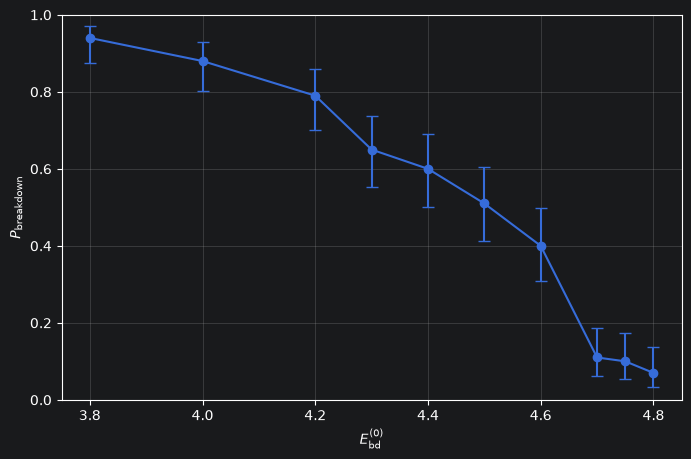

In [16]:
plt.figure(figsize=(8, 5))

yerr = np.vstack([
    breakdown_summary["p_breakdown"]
    - breakdown_summary["ci_low"],

    breakdown_summary["ci_high"]
    - breakdown_summary["p_breakdown"],
])

plt.errorbar(
    breakdown_summary["threshold"],
    breakdown_summary["p_breakdown"],
    yerr=yerr,
    marker="o",
    capsize=4,
)

plt.xlabel(
    r"$E_{\mathrm{bd}}^{(0)}$"
)

plt.ylabel(
    r"$P_{\mathrm{breakdown}}$"
)

plt.ylim(0, 1)

plt.grid(alpha=0.3)

plt.show()

In [17]:
contingency_table = pd.crosstab(
    pilot_results["threshold"],
    pilot_results["status"],
)

from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("chi2 =", chi2)
print("p-value =", p_value)
print("degrees of freedom =", dof)

chi2 = 384.6184618461847
p-value = 2.6148881720035813e-77
degrees of freedom = 9


In [18]:
steps_summary = (
    pilot_results[
        pilot_results["status"] == "arrested"
    ]
    .groupby("threshold")["steps"]
    .agg(["count", "mean", "var"])
)

steps_summary["dispersion"] = (
    steps_summary["var"]
    / steps_summary["mean"]
)

steps_summary

,count,mean,var,dispersion
threshold,,,,
3.80,6,25.833333,21.766667,0.842581
4.00,12,21.750000,4.568182,0.210031
4.20,21,20.904762,5.490476,0.262642
4.30,35,22.428571,7.899160,0.352192
4.40,40,20.925000,4.583974,0.219067
4.50,49,20.816327,8.569728,0.411683
4.60,60,19.600000,5.125424,0.261501
4.70,89,19.460674,4.842186,0.248819
4.75,90,19.211111,5.292010,0.275466


In [21]:
arrested_results = (
    pilot_results[
        pilot_results["status"] == "arrested"
    ]
    .copy()
)

def bootstrap_mean_ci(
    values,
    n_bootstrap=5000,
    confidence_level=0.95,
    seed=42,
):
    rng = np.random.default_rng(seed)

    values = np.asarray(values)

    bootstrap_means = np.empty(
        n_bootstrap
    )

    for i in range(n_bootstrap):
        sample = rng.choice(
            values,
            size=len(values),
            replace=True,
        )

        bootstrap_means[i] = (
            sample.mean()
        )

    alpha = 1 - confidence_level

    ci_low = np.quantile(
        bootstrap_means,
        alpha / 2,
    )

    ci_high = np.quantile(
        bootstrap_means,
        1 - alpha / 2,
    )

    return (
        values.mean(),
        ci_low,
        ci_high,
    )

steps_ci_records = []

for threshold, group in (
    arrested_results
    .groupby("threshold")
):
    mean_steps, ci_low, ci_high = (
        bootstrap_mean_ci(
            group["steps"].to_numpy(),
            n_bootstrap=5000,
            confidence_level=confidence_level,
            seed=42,
        )
    )

    steps_ci_records.append({
        "threshold": threshold,
        "n_arrested": len(group),
        "mean_steps": mean_steps,
        "ci_low": ci_low,
        "ci_high": ci_high,
    })


steps_ci = pd.DataFrame(
    steps_ci_records
)

steps_ci

,threshold,n_arrested,mean_steps,ci_low,ci_high
0,3.80,6,25.833333,23.333333,29.666667
1,4.00,12,21.750000,20.666667,23.000000
2,4.20,21,20.904762,19.952381,21.904762
3,4.30,35,22.428571,21.514286,23.314286
4,4.40,40,20.925000,20.275000,21.600000
5,4.50,49,20.816327,20.000000,21.632653
6,4.60,60,19.600000,19.033333,20.183750
7,4.70,89,19.460674,19.011236,19.921348
8,4.75,90,19.211111,18.733333,19.677778
9,4.80,93,18.677419,18.204301,19.182796


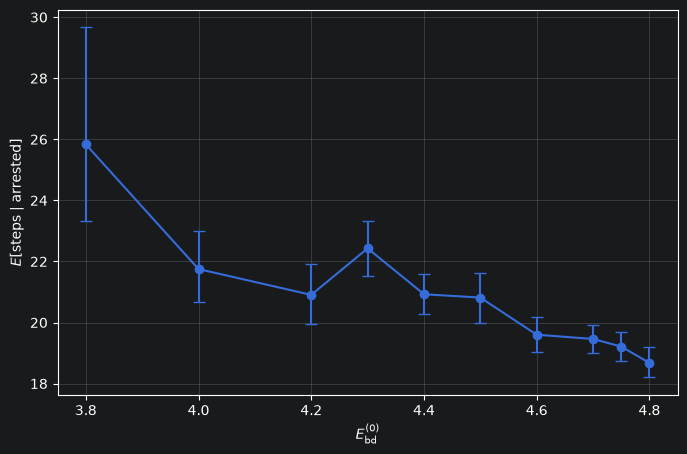

In [22]:
plt.figure(figsize=(8, 5))

yerr = np.vstack([
    steps_ci["mean_steps"]
    - steps_ci["ci_low"],

    steps_ci["ci_high"]
    - steps_ci["mean_steps"],
])

plt.errorbar(
    steps_ci["threshold"],
    steps_ci["mean_steps"],
    yerr=yerr,
    marker="o",
    capsize=4,
)

plt.xlabel(
    r"$E_{\mathrm{bd}}^{(0)}$"
)

plt.ylabel(
    r"$E[\mathrm{steps}\mid\mathrm{arrested}]$"
)

plt.grid(alpha=0.3)

plt.show()

In [26]:
from scipy.stats import linregress

rng = np.random.default_rng(42)

n_bootstrap = 5000
bootstrap_slopes = np.empty(n_bootstrap)
slope, intercept, r_value, p_value, std_err = linregress(
    arrested_results["threshold"],
    arrested_results["steps"],
)
threshold_groups = [
    group
    for _, group in arrested_results.groupby("threshold")
]

for i in range(n_bootstrap):
    sampled_groups = []

    for group in threshold_groups:
        sampled_group = group.sample(
            n=len(group),
            replace=True,
            random_state=int(
                rng.integers(0, 2**32 - 1)
            ),
        )

        sampled_groups.append(
            sampled_group
        )

    sample = pd.concat(
        sampled_groups,
        ignore_index=True,
    )

    bootstrap_slopes[i] = linregress(
        sample["threshold"],
        sample["steps"]
    ).slope

    slope_ci_low = np.quantile(
    bootstrap_slopes,
    0.025,
)

slope_ci_high = np.quantile(
    bootstrap_slopes,
    0.975,
)

print("slope =", slope)
print(
    "95% bootstrap CI =",
    slope_ci_low,
    slope_ci_high,
)

slope = -5.360074174662153
95% bootstrap CI = -6.503298067820917 -4.27136323593013


## Итог по Monte Carlo

Для каждого значения базового порога пробоя было выполнено 100 независимых реализаций при фиксированной структуре материала.

### Вероятность пробоя

При увеличении базового порога

$$
E_{\mathrm{bd}}^{(0)}: 3.8 \rightarrow 4.8
$$

вероятность полного пробоя уменьшается:

$$
P_{\mathrm{breakdown}}: 0.94 \rightarrow 0.07.
$$

Около

$$
E_{\mathrm{bd}}^{(0)} \approx 4.5
$$

получено

$$
P_{\mathrm{breakdown}} \approx 0.5,
$$

то есть эта область соответствует переходу между полным пробоем и остановкой канала.

Для вероятностей построены 95% доверительные интервалы Уилсона.

Критерий Пирсона $\chi^2$ отвергает при уровне значимости

$$
\alpha = 0.05
$$

гипотезу о том, что вероятность пробоя одинакова при всех исследованных значениях $E_{\mathrm{bd}}^{(0)}$.

### Число шагов до остановки

Для остановившихся каналов исследовалось число шагов `steps`.

Для большинства значений порога получено

$$
\frac{\mathrm{Var}(\mathrm{steps})}
{\mathbb{E}[\mathrm{steps}]}
\approx 0.2 - 0.4.
$$

Для распределения Пуассона это отношение должно быть близко к единице, поэтому распределение числа шагов до остановки не согласуется с пуассоновской моделью.

Также обнаружена отрицательная зависимость среднего числа шагов от порога:

$$
\frac{d\,\mathbb{E}[\mathrm{steps}\mid\mathrm{arrested}]}
{dE_{\mathrm{bd}}^{(0)}}
\approx -5.36.
$$

95% bootstrap-интервал для наклона:

$$
[-6.50,\,-4.27].
$$

Поскольку весь интервал отрицателен, в полученной выборке рост $E_{\mathrm{bd}}^{(0)}$ связан с уменьшением числа шагов до остановки.

### Физический вывод

Увеличение $E_{\mathrm{bd}}^{(0)}$ повышает локальные пороги пробоя материала. Поэтому рост канала становится менее устойчивым: вероятность достижения верхнего электрода уменьшается, а остановившиеся каналы в среднем прекращают рост раньше.

Таким образом, в исследованном диапазоне $E_{\mathrm{bd}}^{(0)}$ управляет как вероятностью полного пробоя, так и характерной длиной роста канала до его остановки.

In [27]:
pilot_results.to_csv(
    "monte_carlo_results.csv",
    index=False
)